In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df_loan = pd.read_csv('loan-train.csv')

# 2. Check for duplicates
print(f"Duplicate records found: {df_loan.duplicated().sum()}")

# 3. Handle Missing Values
# Numerical columns (median se fill karenge)
df_loan['LoanAmount'] = df_loan['LoanAmount'].fillna(df_loan['LoanAmount'].median())
df_loan['Loan_Amount_Term'] = df_loan['Loan_Amount_Term'].fillna(df_loan['Loan_Amount_Term'].median())
df_loan['Credit_History'] = df_loan['Credit_History'].fillna(df_loan['Credit_History'].median())

# Categorical columns (mode/most frequent se fill karenge)
df_loan['Gender'] = df_loan['Gender'].fillna(df_loan['Gender'].mode()[0])
df_loan['Married'] = df_loan['Married'].fillna(df_loan['Married'].mode()[0])
df_loan['Dependents'] = df_loan['Dependents'].fillna(df_loan['Dependents'].mode()[0])
df_loan['Self_Employed'] = df_loan['Self_Employed'].fillna(df_loan['Self_Employed'].mode()[0])

print("\n--- Missing Values After Cleaning ---")
print(df_loan.isnull().sum())

Duplicate records found: 0

--- Missing Values After Cleaning ---
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [69]:
print("--- Applicant Income Summary ---")
print(df_loan['ApplicantIncome'].describe())

print("\n--- Loan Status Distribution ---")
print(df_loan['Loan_Status'].value_counts(normalize=True) * 100)

print("\n--- Education Level Distribution ---")
print(df_loan['Education'].value_counts())

--- Applicant Income Summary ---
count    1614.000
mean     8746.305
std      6249.885
min       150.000
25%      3675.250
50%      7045.000
75%     13251.000
max     81000.000
Name: ApplicantIncome, dtype: float64

--- Loan Status Distribution ---
Loan_Status
Y   56.691
N   43.309
Name: proportion, dtype: float64

--- Education Level Distribution ---
Education
Graduate        952
Not Graduate    662
Name: count, dtype: int64


In [70]:
# Outlier thresholds checking using IQR for ApplicantIncome
Q1 = df_loan['ApplicantIncome'].quantile(0.25)
Q3 = df_loan['ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1
outliers_count = ((df_loan['ApplicantIncome'] < (Q1 - 1.5 * IQR)) | (df_loan['ApplicantIncome'] > (Q3 + 1.5 * IQR))).sum()

print(f"Total outlier records found in Applicant Income: {outliers_count}")

Total outlier records found in Applicant Income: 7


In [71]:
# Credit History vs Loan Status
print("--- Credit History vs Loan Status Cross-tab ---")
print(pd.crosstab(df_loan['Credit_History'], df_loan['Loan_Status'], normalize='index') * 100)

# Education vs Loan Status
print("\n--- Education vs Loan Status Cross-tab ---")
print(pd.crosstab(df_loan['Education'], df_loan['Loan_Status'], normalize='index') * 100)

--- Credit History vs Loan Status Cross-tab ---
Loan_Status         N      Y
Credit_History              
0.000          55.088 44.912
1.000          36.877 63.123

--- Education vs Loan Status Cross-tab ---
Loan_Status       N      Y
Education                 
Graduate     40.966 59.034
Not Graduate 46.677 53.323


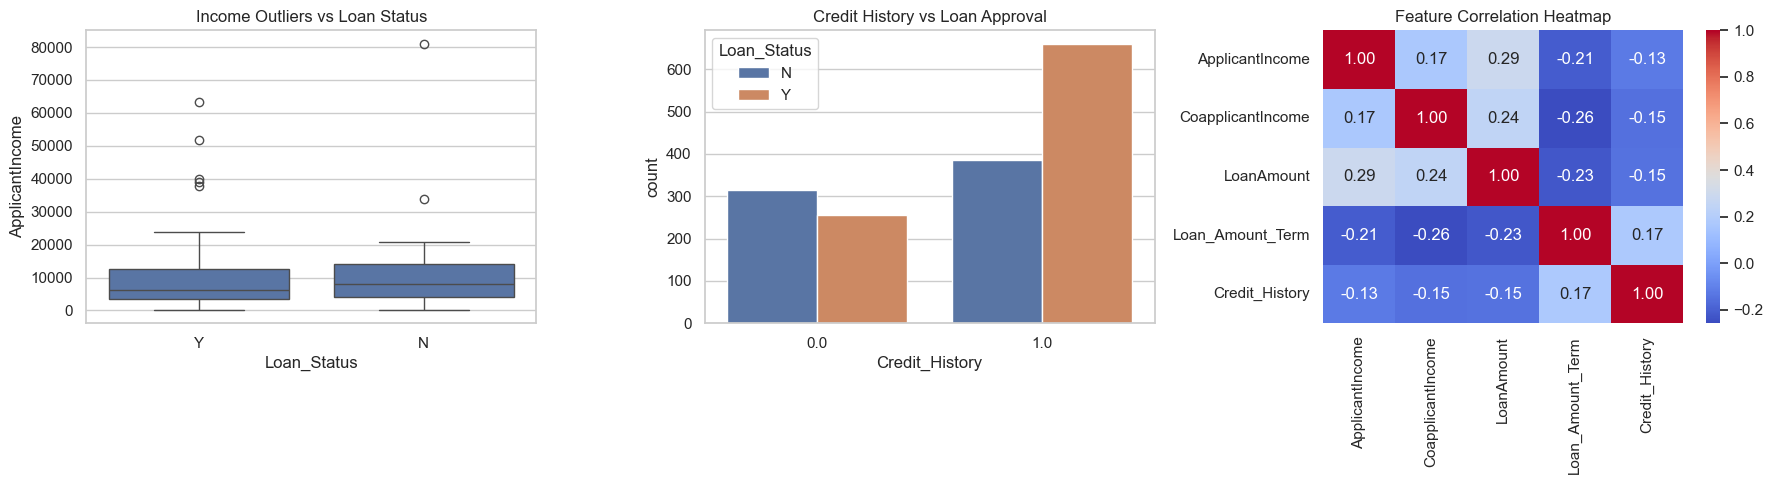

In [72]:
# Setup subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Outliers in Income
sns.boxplot(y='ApplicantIncome', x='Loan_Status', data=df_loan, ax=axes[0])
axes[0].set_title('Income Outliers vs Loan Status')

# 2. Credit History Impact
sns.countplot(x='Credit_History', hue='Loan_Status', data=df_loan, ax=axes[1])
axes[1].set_title('Credit History vs Loan Approval')

# 3. Correlation Heatmap
# Select only numeric columns for correlation
numeric_cols = df_loan.select_dtypes(include=[np.number]).columns
sns.heatmap(df_loan[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()